In [1]:
import sys
sys.path.append('../')

import numpy as np
import pickle

from conformal_clustering.utils import ConformalClustering, sample_gmm, label_alignment, GMMCutoff

from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

### 2D Example with 3 Isotropic Components Using Fuzzy C-Means
(GMM2D3v1)

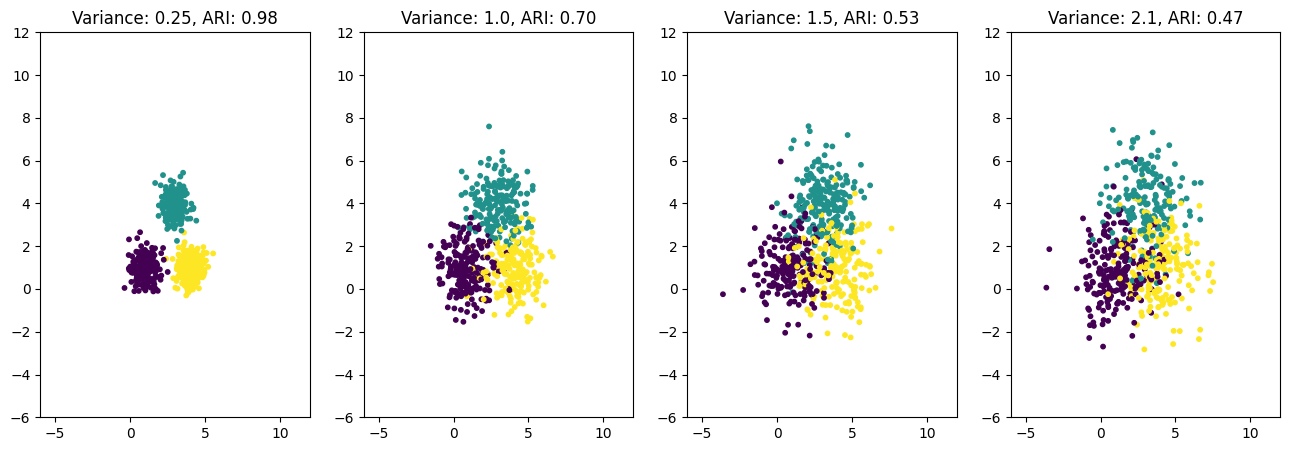

In [2]:
K = 3
means = np.array([[1, 1], [3, 4], [4, 1]])
base_covariances = np.array([np.eye(2) for _ in range(K)])
weights = np.ones(K) / K


var_range = [0.25, 1.0, 1.5, 2.1]

fig, axes = plt.subplots(1, len(var_range), figsize=(int(4*len(var_range)), 5))

for ax, var in zip(axes, var_range):
    covariances = base_covariances * var
    X, y = sample_gmm(means, covariances, weights, K*200)
    gmm = GaussianMixture(n_components=K, covariance_type='diag', random_state=0)
    gmm.fit(X)
    y_pred = gmm.predict(X)
    ari = adjusted_rand_score(y, y_pred)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=10)
    ax.set_title(f'Variance: {var}, ARI: {ari:.2f}')
    ax.set_xlim(-6, 12)
    ax.set_ylim(-6, 12)

plt.show()

### **Fixed Sample Size**

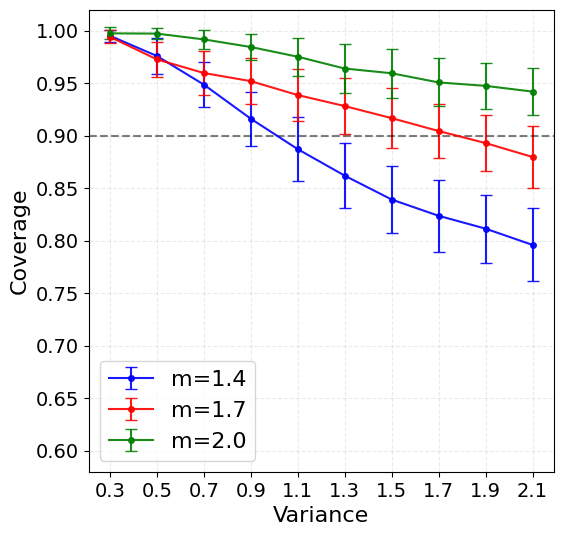

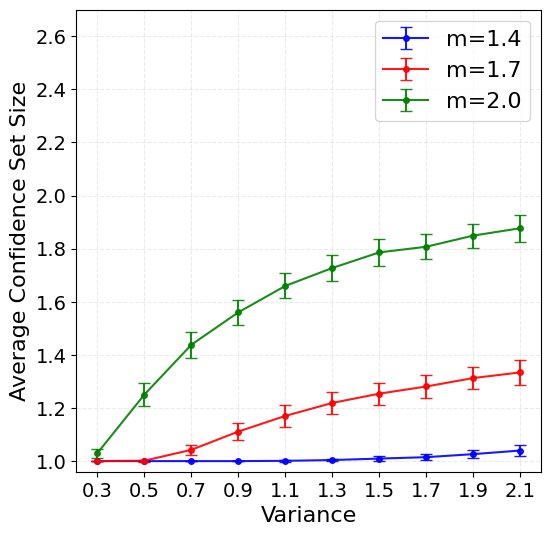

In [3]:
B = 4000
var_range = np.linspace(0.3, 2.1, 10)

with open(f'Results/GMM2D3v1FCM.pkl', 'rb') as f:
    results = pickle.load(f)

covs_FCMS1, sizes_FCMS1 = np.zeros((len(var_range), B)), np.zeros((len(var_range), B))
covs_FCMS2, sizes_FCMS2 = np.zeros((len(var_range), B)), np.zeros((len(var_range), B))
covs_FCMS3, sizes_FCMS3 = np.zeros((len(var_range), B)), np.zeros((len(var_range), B))


for var_idx in range(len(var_range)):
    for b in range(B):
        res = results[var_idx*B + b]
        covs_FCMS1[var_idx, b], sizes_FCMS1[var_idx, b] = res['FCMS1']
        covs_FCMS2[var_idx, b], sizes_FCMS2[var_idx, b] = res['FCMS2']
        covs_FCMS3[var_idx, b], sizes_FCMS3[var_idx, b] = res['FCMS3']

# Each row is reshaped to (B//100, 100)
covs_FCMS1 = np.reshape(covs_FCMS1, (len(var_range), -1, 100))
covs_FCMS2 = np.reshape(covs_FCMS2, (len(var_range), -1, 100))
covs_FCMS3 = np.reshape(covs_FCMS3, (len(var_range), -1, 100))
sizes_FCMS1 = np.reshape(sizes_FCMS1, (len(var_range), -1, 100))
sizes_FCMS2 = np.reshape(sizes_FCMS2, (len(var_range), -1, 100))
sizes_FCMS3 = np.reshape(sizes_FCMS3, (len(var_range), -1, 100))

# Average over the last axis = reshape to (len(var_range), B//100)
covs_FCMS1 = np.mean(covs_FCMS1, axis=2)
covs_FCMS2 = np.mean(covs_FCMS2, axis=2)
covs_FCMS3 = np.mean(covs_FCMS3, axis=2)
sizes_FCMS1 = np.mean(sizes_FCMS1, axis=2)
sizes_FCMS2 = np.mean(sizes_FCMS2, axis=2)
sizes_FCMS3 = np.mean(sizes_FCMS3, axis=2)

# Mean and std over B//100 experiments
covs_FCMS1_mean, covs_FCMS1_std = np.mean(covs_FCMS1, axis=1), np.std(covs_FCMS1, axis=1)
covs_FCMS2_mean, covs_FCMS2_std = np.mean(covs_FCMS2, axis=1), np.std(covs_FCMS2, axis=1)
covs_FCMS3_mean, covs_FCMS3_std = np.mean(covs_FCMS3, axis=1), np.std(covs_FCMS3, axis=1)
sizes_FCMS1_mean, sizes_FCMS1_std = np.mean(sizes_FCMS1, axis=1), np.std(sizes_FCMS1, axis=1)
sizes_FCMS2_mean, sizes_FCMS2_std = np.mean(sizes_FCMS2, axis=1), np.std(sizes_FCMS2, axis=1)
sizes_FCMS3_mean, sizes_FCMS3_std = np.mean(sizes_FCMS3, axis=1), np.std(sizes_FCMS3, axis=1)


# Errorbars with connected lines
plt.figure(figsize=(6,6))
plt.errorbar(var_range, covs_FCMS1_mean, yerr=covs_FCMS1_std, fmt='bo-', capsize=4, markersize=4, alpha=0.9, label=f'm={1.4}')
plt.errorbar(var_range, covs_FCMS2_mean, yerr=covs_FCMS2_std, fmt='ro-', capsize=4, markersize=4, alpha=0.9, label=f'm={1.7}')
plt.errorbar(var_range, covs_FCMS3_mean, yerr=covs_FCMS3_std, fmt='go-', capsize=4, markersize=4, alpha=0.9, label=f'm={2.0}')
plt.axhline(y=0.9, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Variance', fontsize=16)
plt.xticks(ticks=var_range, labels=[f"{v:.1f}" for v in var_range], fontsize=14)
plt.ylabel('Coverage', fontsize=16)
plt.yticks(fontsize=14)
plt.legend(fontsize=16)
plt.grid(True, linestyle="--", alpha=0.25)
plt.ylim((0.58, 1.02))
#plt.savefig('Figures/GMM2D3v1FCM_coverage.pdf', bbox_inches='tight')
plt.show()


plt.figure(figsize=(6,6))
plt.errorbar(var_range, sizes_FCMS1_mean, yerr=sizes_FCMS1_std, fmt='bo-', capsize=4, markersize=4, alpha=0.9, label=f'm={1.4}')
plt.errorbar(var_range, sizes_FCMS2_mean, yerr=sizes_FCMS2_std, fmt='ro-', capsize=4, markersize=4, alpha=0.9, label=f'm={1.7}')
plt.errorbar(var_range, sizes_FCMS3_mean, yerr=sizes_FCMS3_std, fmt='go-', capsize=4, markersize=4, alpha=0.9, label=f'm={2.0}')
plt.xlabel('Variance', fontsize=16)
plt.xticks(ticks=var_range, labels=[f"{v:.1f}" for v in var_range], fontsize=14)
plt.ylabel('Average Confidence Set Size', fontsize=16)
plt.yticks(fontsize=14)
plt.legend(fontsize=16)
plt.grid(True, linestyle="--", alpha=0.25)
plt.ylim((0.96, 2.7))
#plt.savefig('Figures/GMM2D3v1FCM_size.pdf', bbox_inches='tight')
plt.show()

## **Asymptotic: Increasing Sample Size**

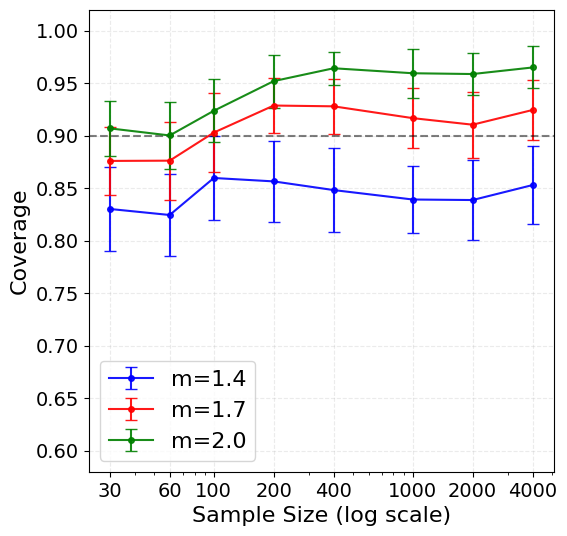

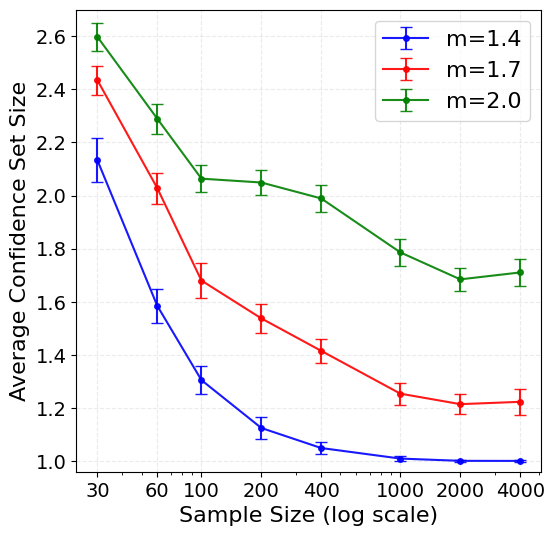

In [4]:
B = 4000
n_range = [30, 60, 100, 200, 400, 1000, 2000, 4000]

with open(f'Results/GMM2D3v1FCM_asymp.pkl', 'rb') as f:
    results = pickle.load(f)

asymp_covs_FCMS1, asymp_sizes_FCMS1 = np.zeros((len(n_range), B)), np.zeros((len(n_range), B))
asymp_covs_FCMS2, asymp_sizes_FCMS2 = np.zeros((len(n_range), B)), np.zeros((len(n_range), B))
asymp_covs_FCMS3, asymp_sizes_FCMS3 = np.zeros((len(n_range), B)), np.zeros((len(n_range), B))


for n_idx in range(len(n_range)):
    for b in range(B):
        res = results[n_idx*B + b]
        asymp_covs_FCMS1[n_idx, b], asymp_sizes_FCMS1[n_idx, b] = res['FCMS1']
        asymp_covs_FCMS2[n_idx, b], asymp_sizes_FCMS2[n_idx, b] = res['FCMS2']
        asymp_covs_FCMS3[n_idx, b], asymp_sizes_FCMS3[n_idx, b] = res['FCMS3']

# Each row is reshaped to (B//100, 100)
asymp_covs_FCMS1 = np.reshape(asymp_covs_FCMS1, (len(n_range), -1, 100))
asymp_covs_FCMS2 = np.reshape(asymp_covs_FCMS2, (len(n_range), -1, 100))
asymp_covs_FCMS3 = np.reshape(asymp_covs_FCMS3, (len(n_range), -1, 100))
asymp_sizes_FCMS1 = np.reshape(asymp_sizes_FCMS1, (len(n_range), -1, 100))
asymp_sizes_FCMS2 = np.reshape(asymp_sizes_FCMS2, (len(n_range), -1, 100))
asymp_sizes_FCMS3 = np.reshape(asymp_sizes_FCMS3, (len(n_range), -1, 100))

# Average over the last axis = reshape to (len(n_range), B//100)
asymp_covs_FCMS1 = np.mean(asymp_covs_FCMS1, axis=2)
asymp_covs_FCMS2 = np.mean(asymp_covs_FCMS2, axis=2)
asymp_covs_FCMS3 = np.mean(asymp_covs_FCMS3, axis=2)
asymp_sizes_FCMS1 = np.mean(asymp_sizes_FCMS1, axis=2)
asymp_sizes_FCMS2 = np.mean(asymp_sizes_FCMS2, axis=2)
asymp_sizes_FCMS3 = np.mean(asymp_sizes_FCMS3, axis=2)

# Mean and std over B//100 experiments
asymp_covs_FCMS1_mean, asymp_covs_FCMS1_std = np.mean(asymp_covs_FCMS1, axis=1), np.std(asymp_covs_FCMS1, axis=1)
asymp_covs_FCMS2_mean, asymp_covs_FCMS2_std = np.mean(asymp_covs_FCMS2, axis=1), np.std(asymp_covs_FCMS2, axis=1)
asymp_covs_FCMS3_mean, asymp_covs_FCMS3_std = np.mean(asymp_covs_FCMS3, axis=1), np.std(asymp_covs_FCMS3, axis=1)
asymp_sizes_FCMS1_mean, asymp_sizes_FCMS1_std = np.mean(asymp_sizes_FCMS1, axis=1), np.std(asymp_sizes_FCMS1, axis=1)
asymp_sizes_FCMS2_mean, asymp_sizes_FCMS2_std = np.mean(asymp_sizes_FCMS2, axis=1), np.std(asymp_sizes_FCMS2, axis=1)
asymp_sizes_FCMS3_mean, asymp_sizes_FCMS3_std = np.mean(asymp_sizes_FCMS3, axis=1), np.std(asymp_sizes_FCMS3, axis=1)


# Errorbars with connected lines (x-axis = sample size in log scale)
plt.figure(figsize=(6,6))
plt.errorbar(n_range, asymp_covs_FCMS1_mean, yerr=asymp_covs_FCMS1_std, fmt='bo-', capsize=4, markersize=4, alpha=0.9, label=f'm={1.4}')
plt.errorbar(n_range, asymp_covs_FCMS2_mean, yerr=asymp_covs_FCMS2_std, fmt='ro-', capsize=4, markersize=4, alpha=0.9, label=f'm={1.7}')
plt.errorbar(n_range, asymp_covs_FCMS3_mean, yerr=asymp_covs_FCMS3_std, fmt='go-', capsize=4, markersize=4, alpha=0.9, label=f'm={2.0}')
plt.axhline(y=0.9, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Sample Size (log scale)', fontsize=16)
plt.xscale('log')
plt.xticks(ticks=n_range, labels=[str(n) for n in n_range], fontsize=14)
plt.ylabel('Coverage', fontsize=16)
plt.yticks(fontsize=14)
plt.legend(fontsize=16)
plt.grid(True, linestyle="--", alpha=0.25)
plt.ylim((0.58, 1.02))
#plt.savefig('Figures/GMM2D3v1FCM_asymp_coverage.pdf', bbox_inches='tight')
plt.show()


plt.figure(figsize=(6,6))
plt.errorbar(n_range, asymp_sizes_FCMS1_mean, yerr=asymp_sizes_FCMS1_std, fmt='bo-', capsize=4, markersize=4, alpha=0.9, label=f'm={1.4}')
plt.errorbar(n_range, asymp_sizes_FCMS2_mean, yerr=asymp_sizes_FCMS2_std, fmt='ro-', capsize=4, markersize=4, alpha=0.9, label=f'm={1.7}')
plt.errorbar(n_range, asymp_sizes_FCMS3_mean, yerr=asymp_sizes_FCMS3_std, fmt='go-', capsize=4, markersize=4, alpha=0.9, label=f'm={2.0}')
plt.xlabel('Sample Size (log scale)', fontsize=16)
plt.xscale('log')
plt.xticks(ticks=n_range, labels=[str(n) for n in n_range], fontsize=14)
plt.ylabel('Average Confidence Set Size', fontsize=16)
plt.yticks(fontsize=14)
plt.legend(fontsize=16)
plt.grid(True, linestyle="--", alpha=0.25)
plt.ylim((0.96, 2.7))
#plt.savefig('Figures/GMM2D3v1FCM_asymp_size.pdf', bbox_inches='tight')
plt.show()

## **Heatmap**

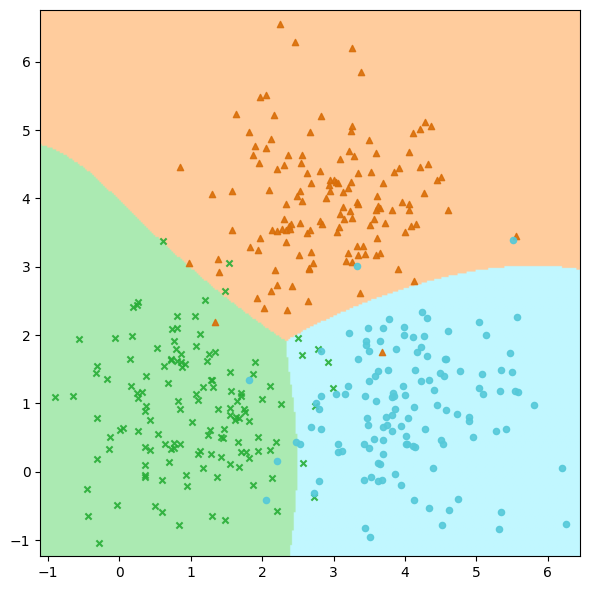

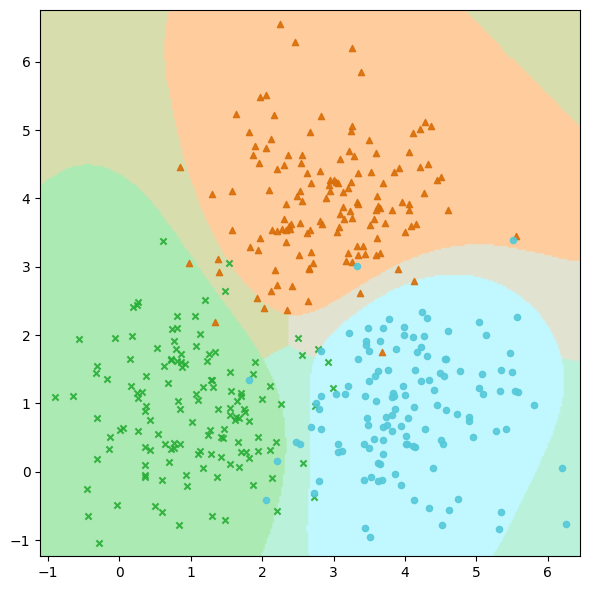

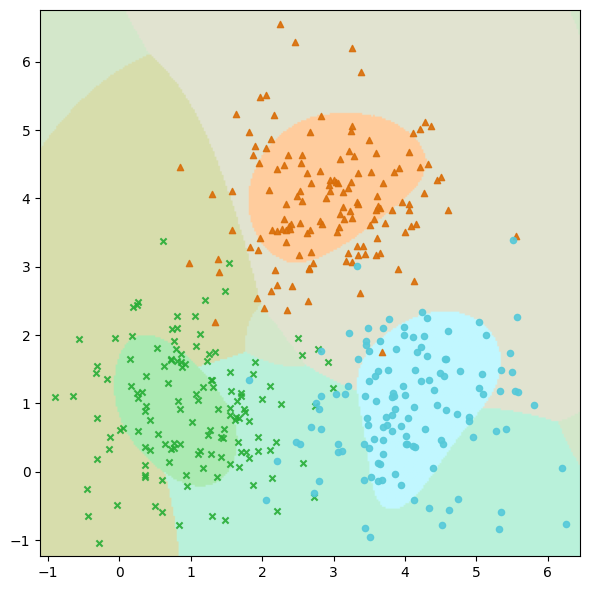

In [5]:
# Core colors
core_hex = {
    2: "#64EDFF83",  # blue
    4: "#FDFF8D",  # orange
    0: "#2ECC40",  # green
    1: "#FF810B",  # red
    3: "#B10DC9",  # purple
}
core_rgb = {k: np.array(mcolors.to_rgb(v), float) for k, v in core_hex.items()}

# Define dark colors for training points
def darken(rgb, factor=0.15):  # 0.15 = 15% darker
    return np.clip(rgb * (1 - factor), 0, 1)

dark_colors = {k: darken(core_rgb[k], 0.15) for k in core_rgb}

def lighten_toward_white(rgb, alpha):
    """alpha in [0,1]: 0 = no change, 1 = white."""
    return (1 - alpha) * rgb + alpha * 1.0

def labels_to_color(labels_like, n_classes=5, base_alpha=0.05):
    """
    - If labels_like is an int -> use that core color.
    - If it's an iterable -> take the mean of the cores in it,
      then 'intensify by number of labels' by moving toward white
      with alpha = base_alpha * (k-1), where k = set size.
      (More labels -> lighter background.)
    """
    # normalize to a Python set of ints
    if isinstance(labels_like, (int, np.integer)):
        S = {int(labels_like)}
    else:
        S = {int(x) for x in labels_like}

    # empty set -> white
    if len(S) == 0:
        return np.array([1.0, 1.0, 1.0], float)

    # mean of the present cores
    mean_rgb = np.mean([core_rgb[i] for i in S], axis=0)

    # intensity control by subset size k
    k = len(S)
    alpha = min(1.0, base_alpha * (k - 1))  # more labels -> lighter
    return lighten_toward_white(mean_rgb, alpha)


# Heatmap 1
n = 400
var = 0.7
covariances = base_covariances * var
X, y = sample_gmm(means, covariances, weights, n_samples=n, seed=2)

X_tr, y_tr = X[:(n//2)], y[:(n//2)] # training
X_cal, y_cal = X[(n//2):n], y[(n//2):n] # calibration

cc = ConformalClustering(X_tr, X_cal)
cc.set_classifier('SVC', random_state=0, probability=True)
cc.fit('FCMS', c=K, m=1.4, error=0.001, maxiter=1000, seed=0)

# Grid over the 2D plane
x_min = X[:,0].min() - 0.2
x_max = X[:,0].max() + 0.2
y_min = X[:,1].min() - 0.2
y_max = X[:,1].max() + 0.2

res = 300
x_range = np.linspace(x_min, x_max, res)
y_range = np.linspace(y_min, y_max, res)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
grid_points = np.column_stack((X_grid.ravel(), Y_grid.ravel())) # flattened grid points

predictions_boolean = cc.conformal_set(grid_points) # conformal prediction for all grid points
oracle_alignment = label_alignment(y_tr, cc.y_tr, 3) # oracle alignment
color_grid = np.array([labels_to_color(oracle_alignment[np.where(predictions_boolean[i])[0]]) for i in range(predictions_boolean.shape[0])])
color_grid = color_grid.reshape((res, res, 3)) # reshape to grid

plt.figure(figsize=(6,6))
plt.imshow(
    color_grid,
    origin='lower',
    extent=(x_min, x_max, y_min, y_max),
    aspect='auto',
    alpha=0.4
)
for label in range(K):
    mask = (y == label)
    if label == 0:
        marker = 'x'
    elif label == 1:
        marker = '^'
    else:
        marker = 'o'
    plt.scatter(
        X[mask, 0],
        X[mask, 1],
        color=dark_colors[label],
        s=20,
        alpha=0.9, 
        marker=marker
    )
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.tight_layout()
plt.show()


# Heatmap 2
cc = ConformalClustering(X_tr, X_cal)
cc.set_classifier('SVC', random_state=0, probability=True)
cc.fit('FCMS', c=K, m=1.7, error=0.001, maxiter=1000, seed=0)
predictions_boolean = cc.conformal_set(grid_points) # conformal prediction for all grid points
oracle_alignment = label_alignment(y_tr, cc.y_tr, 3) # oracle alignment
color_grid = np.array([labels_to_color(oracle_alignment[np.where(predictions_boolean[i])[0]]) for i in range(predictions_boolean.shape[0])])
color_grid = color_grid.reshape((res, res, 3)) # reshape to grid

plt.figure(figsize=(6,6))
plt.imshow(
    color_grid,
    origin='lower',
    extent=(x_min, x_max, y_min, y_max),
    aspect='auto',
    alpha=0.4
)
for label in range(K):
    mask = (y == label)
    if label == 0:
        marker = 'x'
    elif label == 1:
        marker = '^'
    else:
        marker = 'o'
    plt.scatter(
        X[mask, 0],
        X[mask, 1],
        color=dark_colors[label],
        s=20,
        alpha=0.9, 
        marker=marker
    )
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.tight_layout()
plt.show()


# Heatmap 3
cc = ConformalClustering(X_tr, X_cal)
cc.set_classifier('SVC', random_state=0, probability=True)
cc.fit('FCMS', c=K, m=2, error=0.001, maxiter=1000, seed=15)
predictions_boolean = cc.conformal_set(grid_points) # conformal prediction for all grid points
oracle_alignment = label_alignment(y_tr, cc.y_tr, 3) # oracle alignment
color_grid = np.array([labels_to_color(oracle_alignment[np.where(predictions_boolean[i])[0]]) for i in range(predictions_boolean.shape[0])])
color_grid = color_grid.reshape((res, res, 3)) # reshape to grid

plt.figure(figsize=(6,6))
plt.imshow(
    color_grid,
    origin='lower',
    extent=(x_min, x_max, y_min, y_max),
    aspect='auto',
    alpha=0.4
)
for label in range(K):
    mask = (y == label)
    if label == 0:
        marker = 'x'
    elif label == 1:
        marker = '^'
    else:
        marker = 'o'
    plt.scatter(
        X[mask, 0],
        X[mask, 1],
        color=dark_colors[label],
        s=20,
        alpha=0.9, 
        marker=marker
    )
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.tight_layout()
plt.show()

# **Combined Figures**

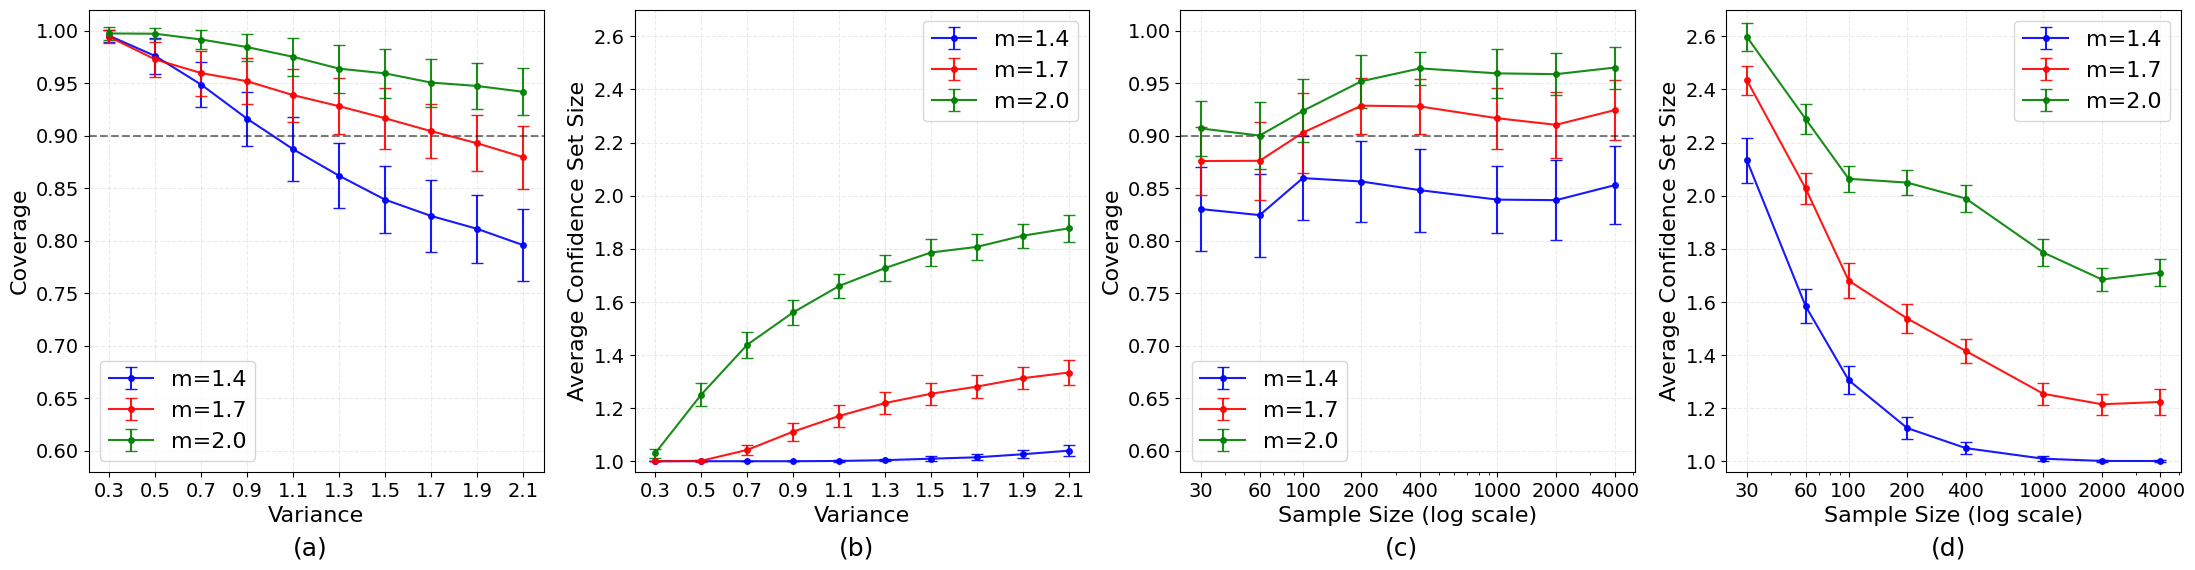

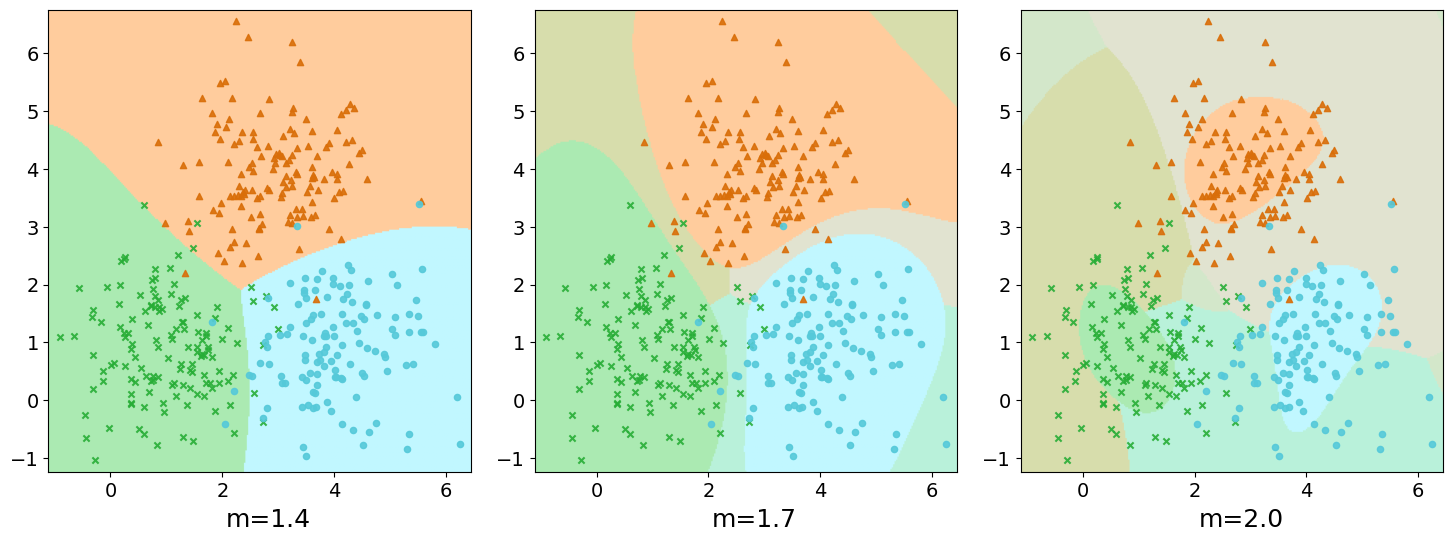

In [6]:
from matplotlib.gridspec import GridSpec

##################################
# Plots combined into one figure #
##################################
fig = plt.figure(figsize=(27, 6))
gs = GridSpec(nrows=1, ncols=4, figure=fig, wspace=0.2, hspace=0.2)

# Coverage (fixed sample size)
ax1 = fig.add_subplot(gs[0, 0])
ax1.errorbar(var_range, covs_FCMS1_mean, yerr=covs_FCMS1_std, fmt='bo-', capsize=4, markersize=4, alpha=0.9, label=f'm={1.4}')
ax1.errorbar(var_range, covs_FCMS2_mean, yerr=covs_FCMS2_std, fmt='ro-', capsize=4, markersize=4, alpha=0.9, label=f'm={1.7}')
ax1.errorbar(var_range, covs_FCMS3_mean, yerr=covs_FCMS3_std, fmt='go-', capsize=4, markersize=4, alpha=0.9, label=f'm={2.0}')
ax1.axhline(y=0.9, color='k', linestyle='--', alpha=0.5)
ax1.set_xlabel('Variance', fontsize=16)
ax1.set_xticks(var_range)
ax1.set_xticklabels(labels=[f"{v:.1f}" for v in var_range], fontsize=14)
ax1.set_ylabel('Coverage', fontsize=16)
ax1.tick_params(axis='y', labelsize=14)
ax1.legend(fontsize=16)
ax1.grid(True, linestyle="--", alpha=0.25)
ax1.set_ylim((0.58, 1.02))

# Size (fixed sample size)
ax2 = fig.add_subplot(gs[0, 1])
ax2.errorbar(var_range, sizes_FCMS1_mean, yerr=sizes_FCMS1_std, fmt='bo-', capsize=4, markersize=4, alpha=0.9, label=f'm={1.4}')
ax2.errorbar(var_range, sizes_FCMS2_mean, yerr=sizes_FCMS2_std, fmt='ro-', capsize=4, markersize=4, alpha=0.9, label=f'm={1.7}')
ax2.errorbar(var_range, sizes_FCMS3_mean, yerr=sizes_FCMS3_std, fmt='go-', capsize=4, markersize=4, alpha=0.9, label=f'm={2.0}')
ax2.set_xlabel('Variance', fontsize=16)
ax2.set_xticks(var_range)
ax2.set_xticklabels(labels=[f"{v:.1f}" for v in var_range], fontsize=14)
ax2.set_ylabel('Average Confidence Set Size', fontsize=16)
ax2.tick_params(axis='y', labelsize=14)
ax2.legend(fontsize=16)
ax2.grid(True, linestyle="--", alpha=0.25)
ax2.set_ylim((0.96, 2.7))

# Asymptotic coverage
ax3 = fig.add_subplot(gs[0, 2])
ax3.errorbar(n_range, asymp_covs_FCMS1_mean, yerr=asymp_covs_FCMS1_std, fmt='bo-', capsize=4, markersize=4, alpha=0.9, label=f'm={1.4}')
ax3.errorbar(n_range, asymp_covs_FCMS2_mean, yerr=asymp_covs_FCMS2_std, fmt='ro-', capsize=4, markersize=4, alpha=0.9, label=f'm={1.7}')
ax3.errorbar(n_range, asymp_covs_FCMS3_mean, yerr=asymp_covs_FCMS3_std, fmt='go-', capsize=4, markersize=4, alpha=0.9, label=f'm={2.0}')
ax3.axhline(y=0.9, color='k', linestyle='--', alpha=0.5)
ax3.set_xlabel('Sample Size (log scale)', fontsize=16)
ax3.set_xscale('log')
ax3.set_xticks(n_range)
ax3.set_xticklabels([str(n) for n in n_range], fontsize=14)
ax3.set_ylabel('Coverage', fontsize=16)
ax3.tick_params(axis='y', labelsize=14)
ax3.legend(fontsize=16)
ax3.grid(True, linestyle="--", alpha=0.25)
ax3.set_ylim((0.58, 1.02))

# Asymptotic size
ax4 = fig.add_subplot(gs[0, 3])
ax4.errorbar(n_range, asymp_sizes_FCMS1_mean, yerr=asymp_sizes_FCMS1_std, fmt='bo-', capsize=4, markersize=4, alpha=0.9, label=f'm={1.4}')
ax4.errorbar(n_range, asymp_sizes_FCMS2_mean, yerr=asymp_sizes_FCMS2_std, fmt='ro-', capsize=4, markersize=4, alpha=0.9, label=f'm={1.7}')
ax4.errorbar(n_range, asymp_sizes_FCMS3_mean, yerr=asymp_sizes_FCMS3_std, fmt='go-', capsize=4, markersize=4, alpha=0.9, label=f'm={2.0}')
ax4.set_xlabel('Sample Size (log scale)', fontsize=16)
ax4.set_xscale('log')
ax4.set_xticks(n_range)
ax4.set_xticklabels([str(n) for n in n_range], fontsize=14)
ax4.set_ylabel('Average Confidence Set Size', fontsize=16)
ax4.tick_params(axis='y', labelsize=14)
ax4.legend(fontsize=16)
ax4.grid(True, linestyle="--", alpha=0.25)
ax4.set_ylim((0.96, 2.7))

ax1.annotate('(a)', xy=(0.45, -0.18), xycoords='axes fraction', fontsize=18, color='black')
ax2.annotate('(b)', xy=(0.45, -0.18), xycoords='axes fraction', fontsize=18, color='black')
ax3.annotate('(c)', xy=(0.45, -0.18), xycoords='axes fraction', fontsize=18, color='black')
ax4.annotate('(d)', xy=(0.45, -0.18), xycoords='axes fraction', fontsize=18, color='black')
plt.savefig('Figures/GMM2D3v1FCM.pdf', bbox_inches='tight')
plt.show()


#####################################
# Heatmaps combined into one figure #
#####################################
fig = plt.figure(figsize=(18, 6))
gs = GridSpec(nrows=1, ncols=3, figure=fig, wspace=0.15, hspace=0.2)

# Heatmap 1
ax1 = fig.add_subplot(gs[0, 0])

n = 400
var = 0.7
covariances = base_covariances * var
X, y = sample_gmm(means, covariances, weights, n_samples=n, seed=2)

X_tr, y_tr = X[:(n//2)], y[:(n//2)] # training
X_cal, y_cal = X[(n//2):n], y[(n//2):n] # calibration

cc = ConformalClustering(X_tr, X_cal)
cc.set_classifier('SVC', random_state=0, probability=True)
cc.fit('FCMS', c=K, m=1.4, error=0.001, maxiter=1000, seed=0)
    
# Grid over the 2D plane
x_min = X[:,0].min() - 0.2
x_max = X[:,0].max() + 0.2
y_min = X[:,1].min() - 0.2
y_max = X[:,1].max() + 0.2

res = 300
x_range = np.linspace(x_min, x_max, res)
y_range = np.linspace(y_min, y_max, res)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
grid_points = np.column_stack((X_grid.ravel(), Y_grid.ravel())) # flattened grid points

predictions_boolean = cc.conformal_set(grid_points) # conformal prediction for all grid points
oracle_alignment = label_alignment(y_tr, cc.y_tr, 3) # oracle alignment
color_grid = np.array([labels_to_color(oracle_alignment[np.where(predictions_boolean[i])[0]]) for i in range(predictions_boolean.shape[0])])
color_grid = color_grid.reshape((res, res, 3)) # reshape to grid

ax1.imshow(
    color_grid,
    origin='lower',
    extent=(x_min, x_max, y_min, y_max),
    aspect='auto',
    alpha=0.4
)
for label in range(K):
    mask = (y == label)
    if label == 0:
        marker = 'x'
    elif label == 1:
        marker = '^'
    else:
        marker = 'o'
    ax1.scatter(
        X[mask, 0],
        X[mask, 1],
        color=dark_colors[label],
        s=20,
        alpha=0.9, 
        marker=marker
    )
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)
ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14)

# Heatmap 2
ax2 = fig.add_subplot(gs[0, 1])

n = 400
var = 0.7
covariances = base_covariances * var
X, y = sample_gmm(means, covariances, weights, n_samples=n, seed=2)

X_tr, y_tr = X[:(n//2)], y[:(n//2)] # training
X_cal, y_cal = X[(n//2):n], y[(n//2):n] # calibration

cc = ConformalClustering(X_tr, X_cal)
cc.set_classifier('SVC', random_state=0, probability=True)
cc.fit('FCMS', c=K, m=1.7, error=0.001, maxiter=1000, seed=0)

# Grid over the 2D plane
x_min = X[:,0].min() - 0.2
x_max = X[:,0].max() + 0.2
y_min = X[:,1].min() - 0.2
y_max = X[:,1].max() + 0.2

res = 300
x_range = np.linspace(x_min, x_max, res)
y_range = np.linspace(y_min, y_max, res)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
grid_points = np.column_stack((X_grid.ravel(), Y_grid.ravel())) # flattened grid points

predictions_boolean = cc.conformal_set(grid_points) # conformal prediction for all grid points
oracle_alignment = label_alignment(y_tr, cc.y_tr, 3) # oracle alignment
color_grid = np.array([labels_to_color(oracle_alignment[np.where(predictions_boolean[i])[0]]) for i in range(predictions_boolean.shape[0])])
color_grid = color_grid.reshape((res, res, 3)) # reshape to grid

ax2.imshow(
    color_grid,
    origin='lower',
    extent=(x_min, x_max, y_min, y_max),
    aspect='auto',
    alpha=0.4
)
for label in range(K):
    mask = (y == label)
    if label == 0:
        marker = 'x'
    elif label == 1:
        marker = '^'
    else:
        marker = 'o'
    ax2.scatter(
        X[mask, 0],
        X[mask, 1],
        color=dark_colors[label],
        s=20,
        alpha=0.9, 
        marker=marker
    )
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)
ax2.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14)

# Heatmap 3
ax3 = fig.add_subplot(gs[0, 2])

n = 400
var = 0.7
covariances = base_covariances * var
X, y = sample_gmm(means, covariances, weights, n_samples=n, seed=2)

X_tr, y_tr = X[:(n//2)], y[:(n//2)] # training
X_cal, y_cal = X[(n//2):n], y[(n//2):n] # calibration

cc = ConformalClustering(X_tr, X_cal)
cc.set_classifier('SVC', random_state=0, probability=True)
cc.fit('FCMS', c=K, m=2, error=0.001, maxiter=1000, seed=15)

# Grid over the 2D plane
x_min = X[:,0].min() - 0.2
x_max = X[:,0].max() + 0.2
y_min = X[:,1].min() - 0.2
y_max = X[:,1].max() + 0.2

res = 300
x_range = np.linspace(x_min, x_max, res)
y_range = np.linspace(y_min, y_max, res)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
grid_points = np.column_stack((X_grid.ravel(), Y_grid.ravel())) # flattened grid points

predictions_boolean = cc.conformal_set(grid_points) # conformal prediction for all grid points
oracle_alignment = label_alignment(y_tr, cc.y_tr, 3) # oracle alignment
color_grid = np.array([labels_to_color(oracle_alignment[np.where(predictions_boolean[i])[0]]) for i in range(predictions_boolean.shape[0])])
color_grid = color_grid.reshape((res, res, 3)) # reshape to grid

ax3.imshow(
    color_grid,
    origin='lower',
    extent=(x_min, x_max, y_min, y_max),
    aspect='auto',
    alpha=0.4
)
for label in range(K):
    mask = (y == label)
    if label == 0:
        marker = 'x'
    elif label == 1:
        marker = '^'
    else:
        marker = 'o'
    ax3.scatter(
        X[mask, 0],
        X[mask, 1],
        color=dark_colors[label],
        s=20,
        alpha=0.9, 
        marker=marker
    )
ax3.set_xlim(x_min, x_max)
ax3.set_ylim(y_min, y_max)
ax3.tick_params(axis='x', labelsize=14)
ax3.tick_params(axis='y', labelsize=14)


ax1.annotate(f'm={1.4}', xy=(0.42, -0.12), xycoords='axes fraction', fontsize=18, color='black')
ax2.annotate(f'm={1.7}', xy=(0.42, -0.12), xycoords='axes fraction', fontsize=18, color='black')
ax3.annotate(f'm={2.0}', xy=(0.42, -0.12), xycoords='axes fraction', fontsize=18, color='black')

plt.savefig('Figures/GMM2D3v1FCM_heatmaps.pdf', bbox_inches='tight')
plt.show()